In [1]:
import numpy as np, pandas as pd
from pathlib import Path

def _root():
    p = Path.cwd().resolve()
    for d in (p, *p.parents):
        if (d/"config.py").exists() and (d/"src").is_dir(): return d
    raise RuntimeError("root not found")
ROOT = _root()
HORIZ = "fwd100"                                        # judge on fwd100 — biggest gap

et = pd.read_parquet(ROOT/"data/model_output_eda/entry_timing/entry_timing_daily.parquet")
dd = pd.read_parquet(ROOT/"data/model_output_eda/regime_state/regime_state_daily_dd.parquet")
df = et.merge(dd[["date","state"]], on="date", how="left").dropna(subset=[HORIZ]).reset_index(drop=True)
f  = df[HORIZ].values                                   # per-day mean top-5 fwd return

assert (df["spy_above200"] == et.set_index("date").loc[df.date,"spy_above200"].values).all()  # panel carries the gate
print(f"{len(df)} deploy dates | {df.date.min():%Y-%m}..{df.date.max():%Y-%m}")
print("states:", df["state"].value_counts().to_dict())

5650 deploy dates | 2003-07..2025-12
states: {'bull-calm': 3464, 'bear': 1094, 'bull-stress': 1092}


In [2]:
def wmean(f, w):                                        # capital-weighted realized mean
    return float(np.sum(w*f) / np.sum(w))

def w_worst_decile(f, w):                               # mean of the worst 10% of DEPLOYED capital
    o = np.argsort(f); fo, wo = f[o], w[o]              # ascending — worst first
    k = np.searchsorted(np.cumsum(wo), 0.10*wo.sum()) + 1
    return wmean(fo[:k], wo[:k])

# sanity: flat weights -> ordinary bottom-decile mean; scale-invariant
_f = np.random.default_rng(0).standard_normal(1000)
assert abs(w_worst_decile(_f, np.ones(1000)) - np.sort(_f)[:100].mean()) < 0.02
assert abs(w_worst_decile(_f, np.full(1000,3.0)) - w_worst_decile(_f, np.ones(1000))) < 1e-9
print("weight math ok")

weight math ok


In [3]:
bull = (df["state"] != "bear").values.astype(float)     # SPY>200d, known at the open

def weights(kind, bear_w=0.0):
    if kind == "flat":   return np.ones(len(df))
    if kind == "spx200": return np.where(bull>0, 1.0, bear_w)          # (a) 2-state
    if kind == "stress":                                              # (b) 6-pillar tilt, bull-gated
        s = df["stress_ew_vix"].values
        z = (s - np.nanmin(s)) / (np.nanmax(s) - np.nanmin(s))        # live composite -> [0,1] tilt
        return bull * np.nan_to_num(z, nan=0.5)                       # bear -> 0 (falling-knife); warmup -> neutral

rules = [("flat","FLAT (no governor)"), ("spx200","(a) SPY-200MA, bear=0"),
         ("stress","(b) stress_ew_vix, bull-gated")]
res = pd.DataFrame([dict(rule=lbl, mean=wmean(f, weights(k)), worst_decile=w_worst_decile(f, weights(k)),
                         deployed_frac=weights(k).sum()/len(df)) for k,lbl in rules])
base = res.iloc[0]
res["d_mean"]  = res["mean"] - base["mean"]
res["d_worst"] = res["worst_decile"] - base["worst_decile"]
pd.set_option("display.float_format", lambda x: f"{x:+.4f}")
print(res.to_string(index=False))
# READ: a governor helps iff d_mean>0 AND d_worst>0 (tail less negative). (a) helps only the tail; (b) helps both.

                         rule    mean  worst_decile  deployed_frac  d_mean  d_worst
           FLAT (no governor) +0.1247       -0.3485        +1.0000 +0.0000  +0.0000
        (a) SPY-200MA, bear=0 +0.1148       -0.2981        +0.8064 -0.0099  +0.0505
(b) stress_ew_vix, bull-gated +0.1331       -0.2889        +0.1784 +0.0084  +0.0596


In [4]:
g = df.groupby("state")[HORIZ]
by_state = pd.DataFrame({
    "mean":         g.mean(),
    "worst_decile": g.apply(lambda x: x.nsmallest(max(1,len(x)//10)).mean()),
    "n":            g.size(),
}).loc[["bull-calm","bull-stress","bear"]]
print(by_state.to_string())
print(f"\nbear pos-share {(df[df.state=='bear'][HORIZ]>0).mean():.0%} "
      f"| bear top-decile {df[df.state=='bear'][HORIZ].nlargest(109).mean():+.0%}  (the rebound)")
# READ: bear has the HIGHEST mean (+16.6%, rebound) AND the worst tail (-51%). (a) cutting bear loses the
#       rebound (mean drops) but removes the knife (tail up). (b) sends capital to bull-stress -> both improve.

               mean  worst_decile     n
state                                  
bull-calm   +0.1128       -0.3062  3464
bull-stress +0.1212       -0.2704  1092
bear        +0.1658       -0.5135  1094

bear pos-share 57% | bear top-decile +137%  (the rebound)


In [5]:
sweep = []
for h in ("fwd20","fwd50","fwd100"):
    d = et.merge(dd[["date","state"]], on="date", how="left").dropna(subset=[h]).reset_index(drop=True)
    b = (d["state"]!="bear").values.astype(float); fh = d[h].values
    def w(kind):
        if kind=="flat":   return np.ones(len(d))
        if kind=="spx200": return np.where(b>0,1.0,0.0)
        s=d["stress_ew_vix"].values; z=(s-np.nanmin(s))/(np.nanmax(s)-np.nanmin(s))
        return b*np.nan_to_num(z,nan=0.5)
    for k in ("flat","spx200","stress"):
        sweep.append(dict(horizon=h, rule=k, mean=wmean(fh,w(k)), worst_decile=w_worst_decile(fh,w(k))))
sw = pd.DataFrame(sweep)
print("mean:\n",         sw.pivot(index="rule",columns="horizon",values="mean").to_string())
print("\nworst-decile:\n", sw.pivot(index="rule",columns="horizon",values="worst_decile").to_string())
# READ: deltas at fwd20 are ~1/3 the fwd100 size. Governor + recovery both live long -> judge on fwd100.

mean:
 horizon  fwd100   fwd20   fwd50
rule                           
flat    +0.1247 +0.0259 +0.0593
spx200  +0.1148 +0.0285 +0.0574
stress  +0.1331 +0.0308 +0.0686

worst-decile:
 horizon  fwd100   fwd20   fwd50
rule                           
flat    -0.3485 -0.2067 -0.2971
spx200  -0.2981 -0.1893 -0.2809
stress  -0.2889 -0.1809 -0.2634


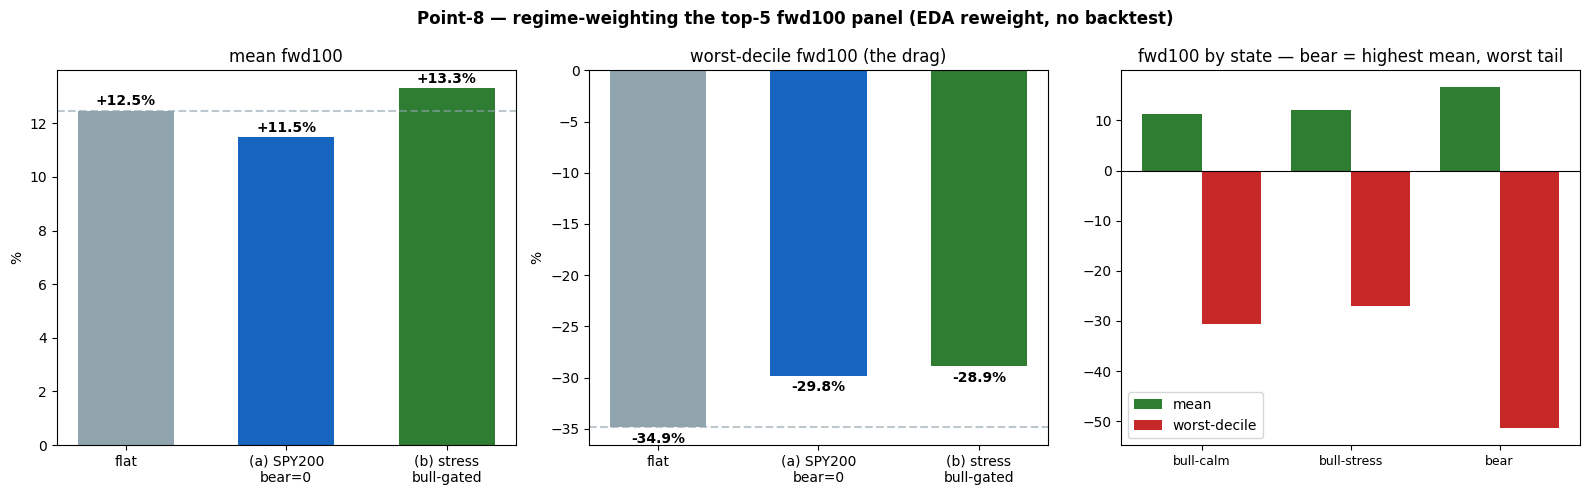

In [6]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(16, 5))
labels = ["flat","(a) SPY200\nbear=0","(b) stress\nbull-gated"]; cols = ["#90a4ae","#1565c0","#2e7d32"]
means = [wmean(f, weights(k)) for k,_ in rules]; worst = [w_worst_decile(f, weights(k)) for k,_ in rules]

b = ax[0].bar(labels, [m*100 for m in means], color=cols, width=.6)
for r,v in zip(b,means): ax[0].text(r.get_x()+.3, v*100+.2, f"{v:+.1%}", ha="center", weight="bold")
ax[0].axhline(means[0]*100, color="#90a4ae", ls="--", alpha=.6); ax[0].set_title("mean fwd100"); ax[0].set_ylabel("%")

b = ax[1].bar(labels, [w*100 for w in worst], color=cols, width=.6)
for r,v in zip(b,worst): ax[1].text(r.get_x()+.3, v*100-1.5, f"{v:+.1%}", ha="center", weight="bold")
ax[1].axhline(worst[0]*100, color="#90a4ae", ls="--", alpha=.6); ax[1].set_title("worst-decile fwd100 (the drag)"); ax[1].set_ylabel("%")

st=["bull-calm","bull-stress","bear"]; x=np.arange(3)
gm=[by_state.loc[s,"mean"]*100 for s in st]; gw=[by_state.loc[s,"worst_decile"]*100 for s in st]
ax[2].bar(x-.2, gm, .4, label="mean", color="#2e7d32"); ax[2].bar(x+.2, gw, .4, label="worst-decile", color="#c62828")
ax[2].set_xticks(x); ax[2].set_xticklabels(st, fontsize=9); ax[2].axhline(0,color="k",lw=.8)
ax[2].set_title("fwd100 by state — bear = highest mean, worst tail"); ax[2].legend()

fig.suptitle("Point-8 — regime-weighting the top-5 fwd100 panel (EDA reweight, no backtest)", weight="bold")
plt.tight_layout(); plt.show()

In [7]:
# One-time reduce (skip if _topN_scratch.parquet exists): keep top-15 by score per day, all 25 years.
import glob
scratch = ROOT/"data/model_output_eda/regime_weight/_topN_scratch.parquet"
if not scratch.exists():
    frames = []
    for fp in sorted(glob.glob(str(ROOT/"data/model_output_eda/multiyear/raw_full_*_fwd.parquet"))):
        d = pd.read_parquet(fp, columns=["date","prob_elite","fwd20","fwd50","fwd100"])
        frames.append(d.sort_values("prob_elite", ascending=False).groupby("date").head(15))
    pd.concat(frames, ignore_index=True).to_parquet(scratch)
topn = pd.read_parquet(scratch)

PERIODS = [("2003-07-01","2007-06-30","2003-07 bull"), ("2007-07-01","2009-06-30","2007-09 GFC"),
           ("2013-01-01","2015-12-31","2013-15 calm bull"), ("2020-01-01","2020-12-31","2020 COVID"),
           ("2022-01-01","2022-12-31","2022 bear"), ("2023-01-01","2025-12-31","2023-25 recent")]

def daily_topn(df_, n, h):                              # mean fwd of the top-n scored names each day
    g = df_.sort_values("prob_elite", ascending=False).groupby("date").head(n)
    return g.groupby("date")[h].mean().sort_index()

print("days", topn.date.nunique(), "|", topn.date.min().date(), "->", topn.date.max().date())

days 6288 | 2001-01-02 -> 2025-12-31


In [8]:
rows = []
for start, end, label in PERIODS:
    sub = topn[(topn.date>=start) & (topn.date<=end)]
    rows.append({"period": label, **{f"top{n}": daily_topn(sub,n,"fwd20").cumsum().diff().mean()*100
                                     for n in (1,5,10)}})
slope = pd.DataFrame(rows).set_index("period")
pd.set_option("display.float_format", lambda x: f"{x:+.2f}")
print("cumulative top-N fwd20 slope  (mean daily increment x100 = ~%/100 deploy-days):")
print(slope.to_string())
# READ: +ve & similar across N => real drift; GFC is NEGATIVE (bleed) -> start-date lottery bites in a crash.

cumulative top-N fwd20 slope  (mean daily increment x100 = ~%/100 deploy-days):
                    top1   top5  top10
period                                
2003-07 bull       +2.03  +2.82  +2.81
2007-09 GFC        -0.41  -1.90  -1.55
2013-15 calm bull  +1.21  +1.60  +1.87
2020 COVID        +11.49 +13.18 +11.45
2022 bear          +4.03  +1.61  +1.37
2023-25 recent     +4.07  +3.21  +2.90


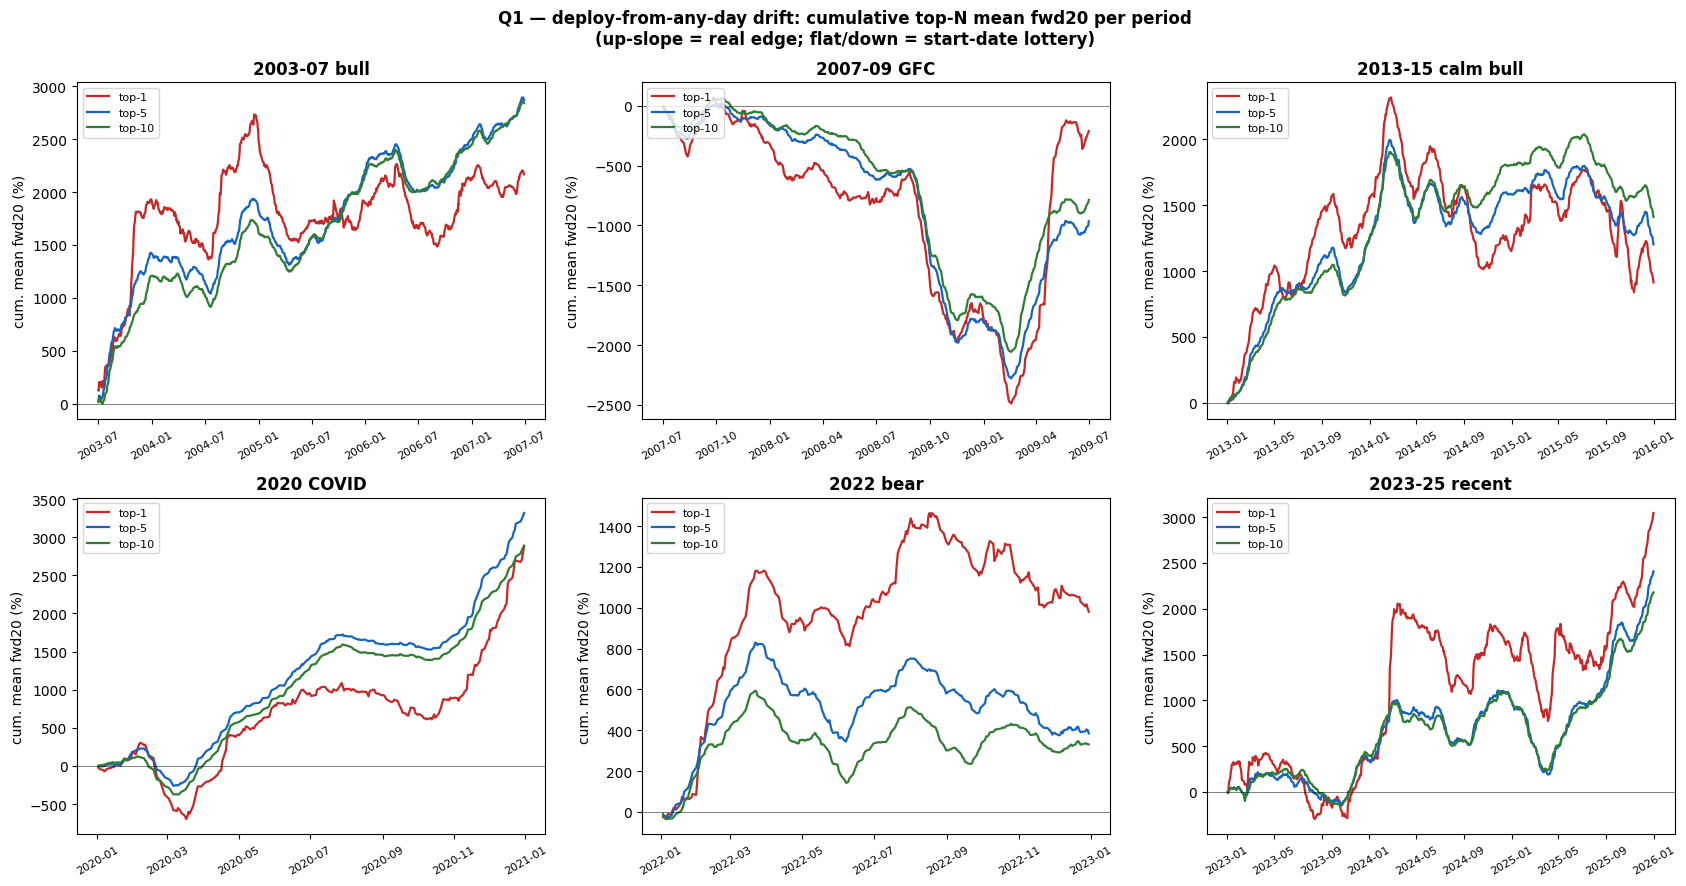

In [9]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(2, 3, figsize=(17, 9)); cols = {1:"#c62828",5:"#1565c0",10:"#2e7d32"}
for a, (start,end,label) in zip(ax.flat, PERIODS):
    sub = topn[(topn.date>=start) & (topn.date<=end)]
    for n in (1,5,10):
        s = daily_topn(sub,n,"fwd20").cumsum()
        a.plot(s.index, s.values*100, color=cols[n], lw=1.6, label=f"top-{n}")
    a.axhline(0, color="k", lw=.7, alpha=.5); a.set_title(label, weight="bold")
    a.set_ylabel("cum. mean fwd20 (%)"); a.legend(fontsize=8, loc="upper left")
    a.tick_params(axis="x", labelrotation=30, labelsize=8)
fig.suptitle("Q1 — deploy-from-any-day drift: cumulative top-N mean fwd20 per period\n"
             "(up-slope = real edge; flat/down = start-date lottery)", weight="bold")
plt.tight_layout(); plt.show()

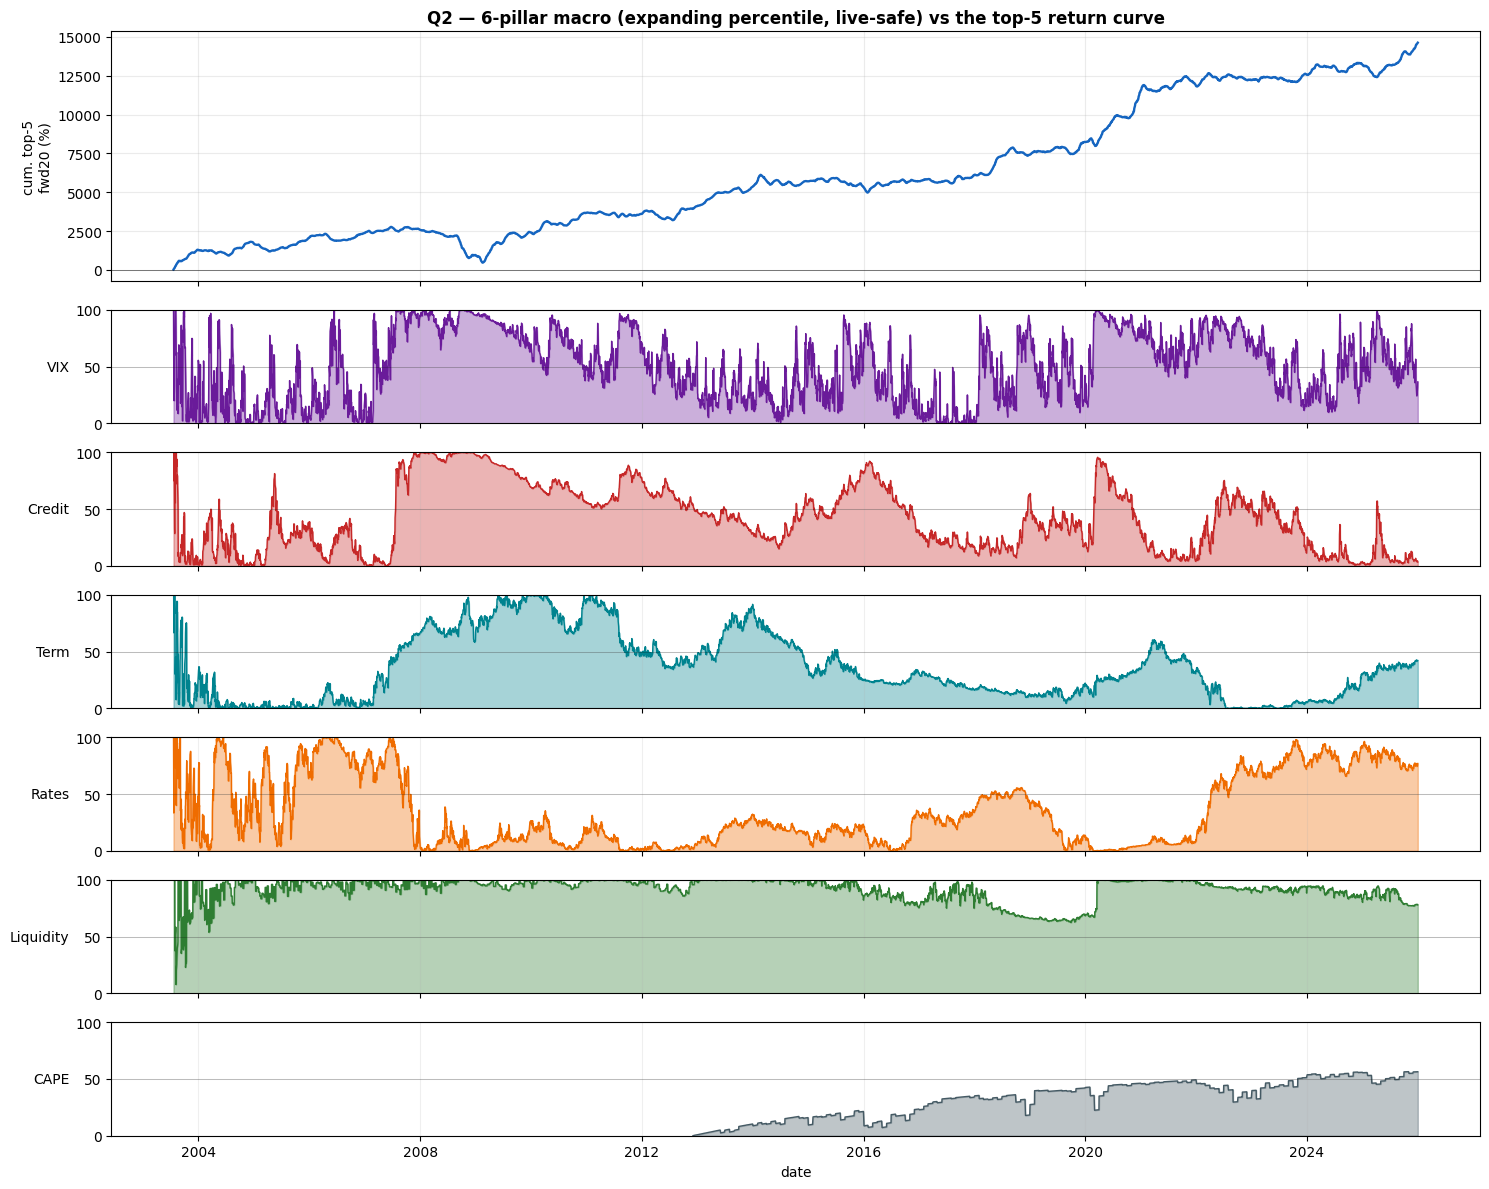

In [10]:
pil = ["pil_vix","pil_credit","pil_term","pil_rates","pil_liq","pil_cape"]
p = et[["date"]+pil].sort_values("date").reset_index(drop=True)
for c in pil:                                          # expanding percentile = rank of today in history-to-date (live-safe)
    p[c+"_pct"] = p[c].expanding().apply(lambda x: (x.iloc[-1] >= x).mean(), raw=False)
curve5 = daily_topn(topn[topn.date>=p.date.min()], 5, "fwd20").cumsum()

nice = {"pil_vix":"VIX","pil_credit":"Credit","pil_term":"Term","pil_rates":"Rates","pil_liq":"Liquidity","pil_cape":"CAPE"}
pcols = ["#6a1b9a","#c62828","#00838f","#ef6c00","#2e7d32","#455a64"]
fig, ax = plt.subplots(7, 1, figsize=(15, 12), sharex=True, gridspec_kw={"height_ratios":[2.2]+[1]*6})
ax[0].plot(curve5.index, curve5.values*100, color="#1565c0", lw=1.7); ax[0].axhline(0,color="k",lw=.7,alpha=.5)
ax[0].set_ylabel("cum. top-5\nfwd20 (%)"); ax[0].grid(alpha=.25)
ax[0].set_title("Q2 — 6-pillar macro (expanding percentile, live-safe) vs the top-5 return curve", weight="bold")
for a, c, col in zip(ax[1:], [c+"_pct" for c in pil], pcols):
    a.fill_between(p.date, 0, p[c]*100, color=col, alpha=.35); a.plot(p.date, p[c]*100, color=col, lw=1)
    a.set_ylim(0,100); a.set_yticks([0,50,100]); a.axhline(50,color="k",lw=.5,alpha=.3); a.grid(alpha=.2)
    a.set_ylabel(nice[c.replace("_pct","")], rotation=0, ha="right", va="center", fontsize=10)
ax[-1].set_xlabel("date"); plt.tight_layout(); plt.show()
# READ: pillars are DAILY-noisy but the low-freq shape tracks regimes — credit/VIX percentile spike into
#       2008 & 2020 (where the curve stalls/dips), CAPE only starts 2012, liquidity jumps at 2020 QE.

### Read — the drift is regime-gated; the pillars are the backdrop, not yet a consolidated signal

- **Q1: deploy-from-any-day drift is REAL in bull/rebound regimes and INVERTS in the GFC.** Cumulative
  top-5 fwd20 slope per 100 deploy-days: 2020 COVID +13.2, 2023-25 +3.2, 2003-07 +2.8, 2013-15 +1.6 —
  all steady up-slopes, so within a bull/recovery the start-DAY barely matters (you drift up whenever
  you start). But 2007-09 GFC is **−1.9**: deploy into the crash and you bleed regardless of the day.
  This IS the regime-blindness redrawn as an equity curve — the edge is a bull-regime property, which
  is exactly why the point-8 governor (gate/tilt off SPY-200d + stress) is the fix.
- **top-5 ≈ top-10, top-1 is the noisy one.** The 5/10 curves track each other (the "sharp cliff at 5,
  flat inside" from [[project_capital_deployment]]); top-1 swings widest (concentration = variance),
  most visibly in 2022. Basket width buys smoothness, not more mean.
- **Q2: the 6 pillars are a legible macro BACKDROP, not yet a consolidated signal.** As expanding
  percentiles they're daily-noisy but the low-frequency shape tracks regimes — credit & VIX percentiles
  spike into 2008 and 2020 (where the curve stalls/dips), rates fall through those windows, CAPE only
  exists 2012+. This is the raw material behind `stress_ew_vix` (+credit −rates −cape +vix); the
  consolidated version is that composite ([[project_entry_timing_macro_axis]]).
  - ⚠️ **EXPANDING percentile is BROKEN for the two TRENDING pillars — see Part 3/C5 for the fix.**
    Net Liquidity (corr w/ time +0.96) and CAPE (+0.91) only ever ramp up, so their expanding percentile
    is pinned at ~100% after 2004 (it just re-encodes "later = higher", not a regime signal). VIX/credit/
    term/rates are cyclical so expanding-pct is fine there. Part 3 replaces it with a ROLLING 2yr
    percentile, which shows the cyclical position for all six.
- **⚠️ Same EDA caveats.** Directional close-to-close fwd returns, no exits/sizing; cumulative sum is a
  deploy-every-day proxy path, not a realized equity curve (no capital constraint, one basket/day
  overlapping). Percentiles are expanding (live-safe) so no look-ahead, but they're a visualization, not
  a fitted feature.

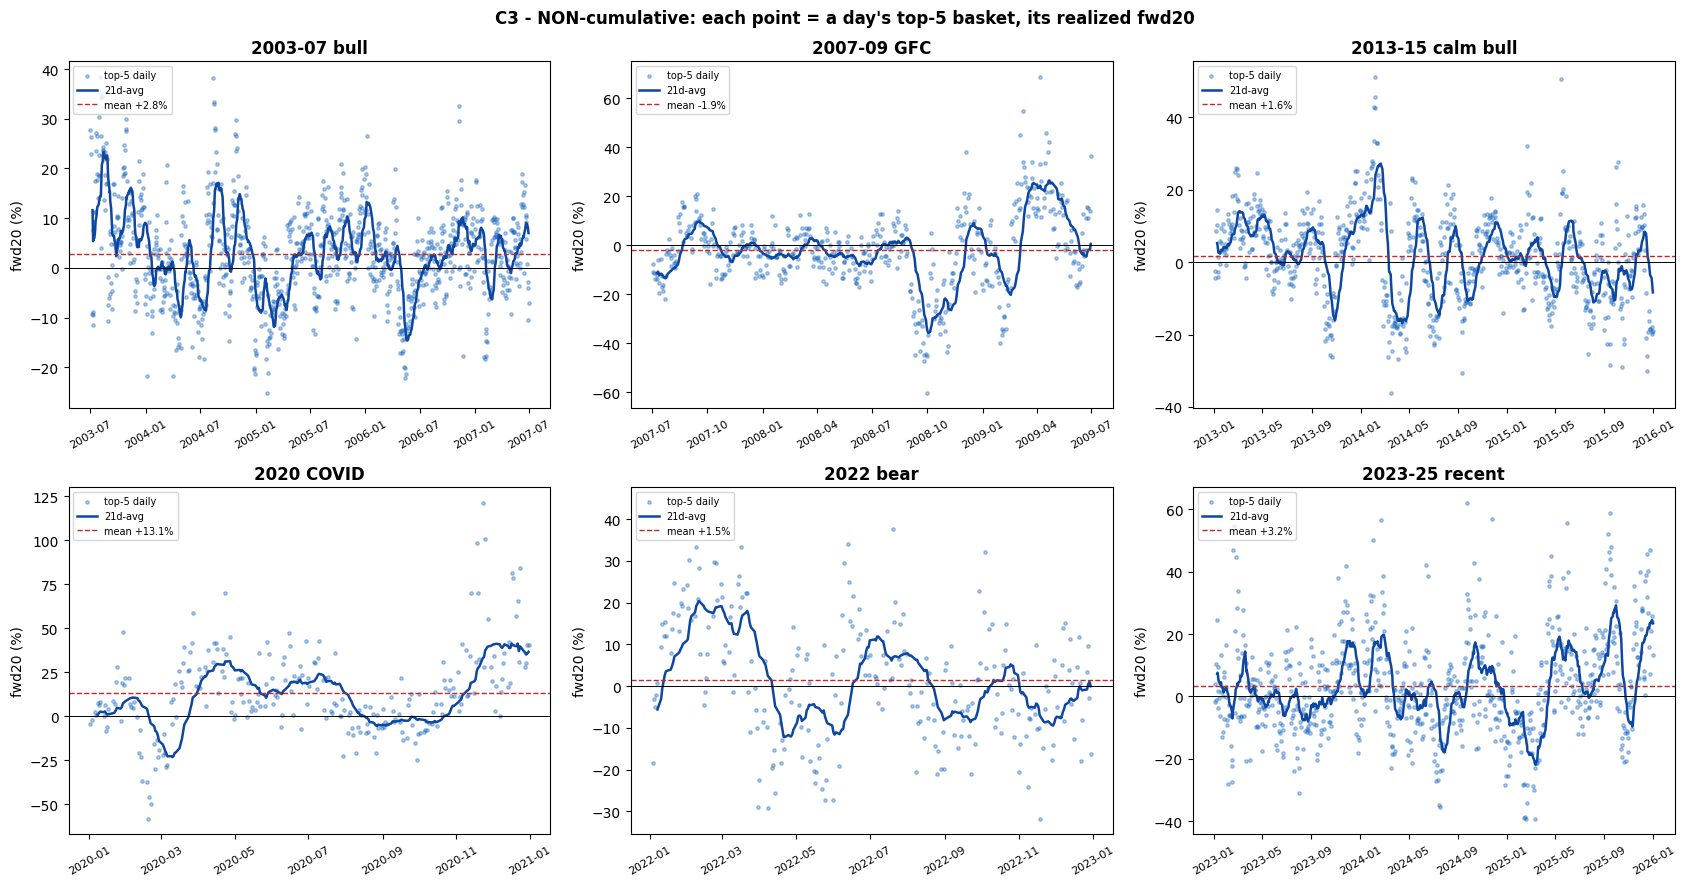

In [11]:
fig, ax = plt.subplots(2, 3, figsize=(17, 9))
for a, (start, end, label) in zip(ax.flat, PERIODS):
    sub = topn[(topn.date>=start) & (topn.date<=end)]
    d5 = daily_topn(sub, 5, "fwd20") * 100                 # each point = one day's top-5 basket, realized fwd20
    a.scatter(d5.index, d5.values, s=6, alpha=.35, color="#1565c0", label="top-5 daily")
    roll = d5.rolling(21, min_periods=5).mean()
    a.plot(roll.index, roll.values, color="#0d47a1", lw=1.8, label="21d-avg")
    a.axhline(0, color="k", lw=.7); a.axhline(d5.mean(), color="#c62828", ls="--", lw=1, label=f"mean {d5.mean():+.1f}%")
    a.set_title(label, weight="bold"); a.set_ylabel("fwd20 (%)")
    a.legend(fontsize=7, loc="upper left"); a.tick_params(axis="x", labelrotation=30, labelsize=8)
fig.suptitle("C3 - NON-cumulative: each point = a day's top-5 basket, its realized fwd20", weight="bold")
plt.tight_layout(); plt.show()
# READ: the cumulative curve is the running SUM of these points. A positive mean line (red) => drift up;
#       GFC/bear panels sit near/below 0 with fat downside scatter.

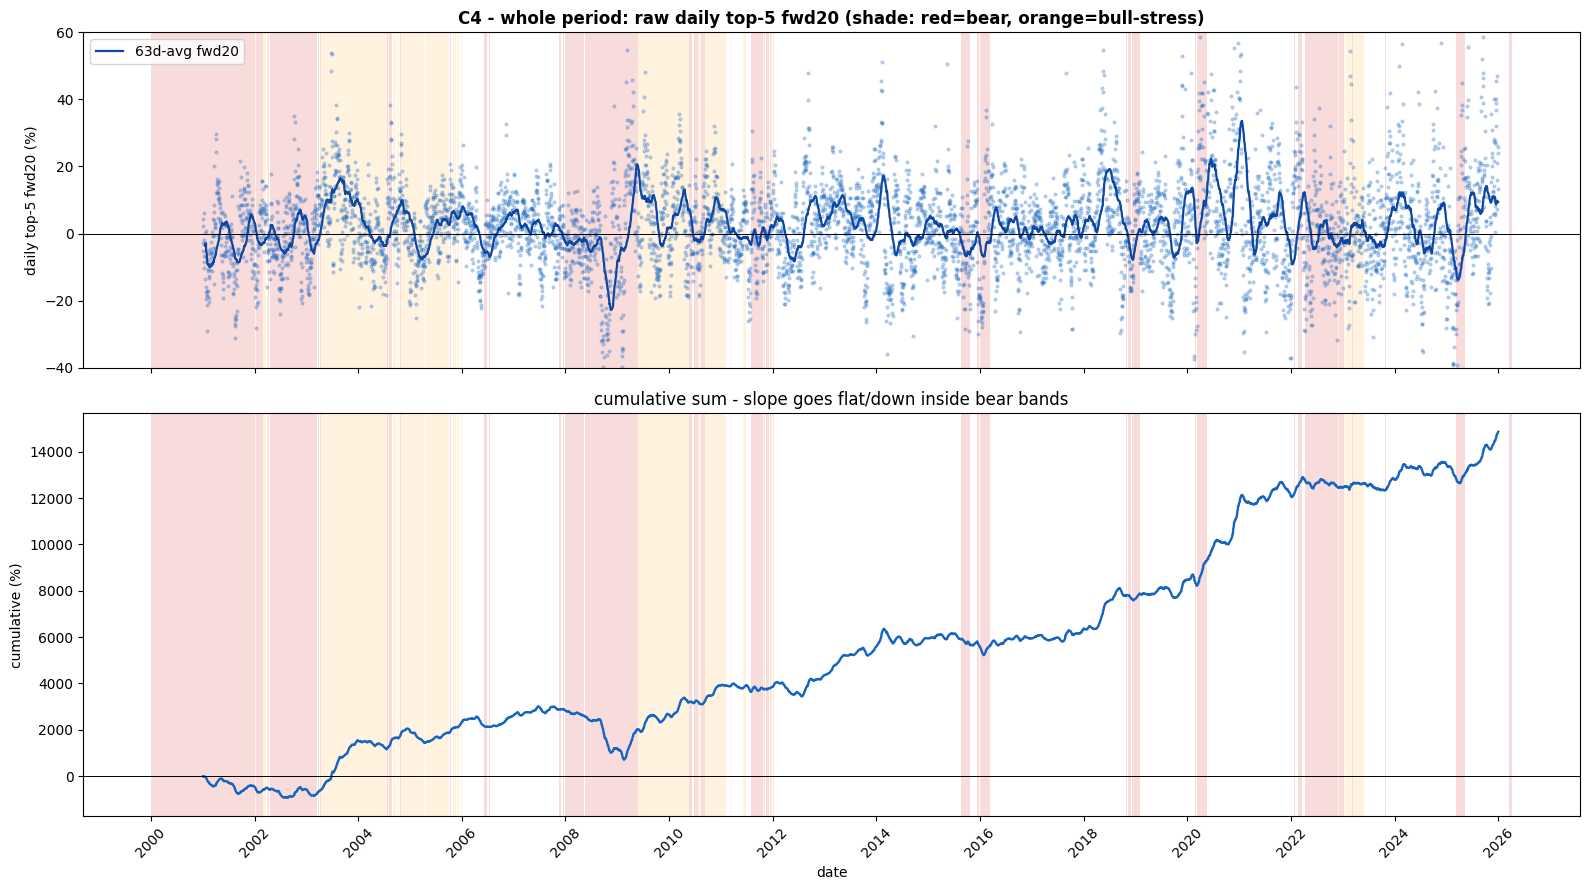

In [12]:
from matplotlib.dates import YearLocator
dd = pd.read_parquet(ROOT/"data/model_output_eda/regime_state/regime_state_daily_dd.parquet")[["date","state"]]

def shade(ax, reg):                                        # red=bear, orange=bull-stress
    r = reg.sort_values("date").reset_index(drop=True); r["blk"] = (r.state != r.state.shift()).cumsum()
    for _, g in r.groupby("blk"):
        col = {"bear":"#e57373","bull-stress":"#ffcc80"}.get(g.state.iloc[0])
        if col: ax.axvspan(g.date.iloc[0], g.date.iloc[-1], color=col, alpha=.25, lw=0)

d5 = daily_topn(topn, 5, "fwd20") * 100
fig, ax = plt.subplots(2, 1, figsize=(16, 9), sharex=True, gridspec_kw={"height_ratios":[1,1.2]})
for a in ax: shade(a, dd)
ax[0].scatter(d5.index, d5.values, s=4, alpha=.25, color="#1565c0")
ax[0].plot(d5.rolling(63,min_periods=10).mean().index, d5.rolling(63,min_periods=10).mean().values,
           color="#0d47a1", lw=1.6, label="63d-avg fwd20")
ax[0].axhline(0,color="k",lw=.7); ax[0].set_ylim(-40,60); ax[0].set_ylabel("daily top-5 fwd20 (%)"); ax[0].legend(loc="upper left")
ax[0].set_title("C4 - whole period: raw daily top-5 fwd20 (shade: red=bear, orange=bull-stress)", weight="bold")
ax[1].plot(d5.index, d5.cumsum().values, color="#1565c0", lw=1.7); ax[1].axhline(0,color="k",lw=.7)
ax[1].set_ylabel("cumulative (%)"); ax[1].set_xlabel("date"); ax[1].xaxis.set_major_locator(YearLocator(2))
ax[1].tick_params(axis="x", labelrotation=45); ax[1].set_title("cumulative sum - slope goes flat/down inside bear bands")
plt.tight_layout(); plt.show()
# READ: the red bear bands (2001-02, 2008, 2020, 2022) line up with the flat/declining stretches of the
#       cumulative curve -> the regime change IS visible; the drift is a bull-regime phenomenon.

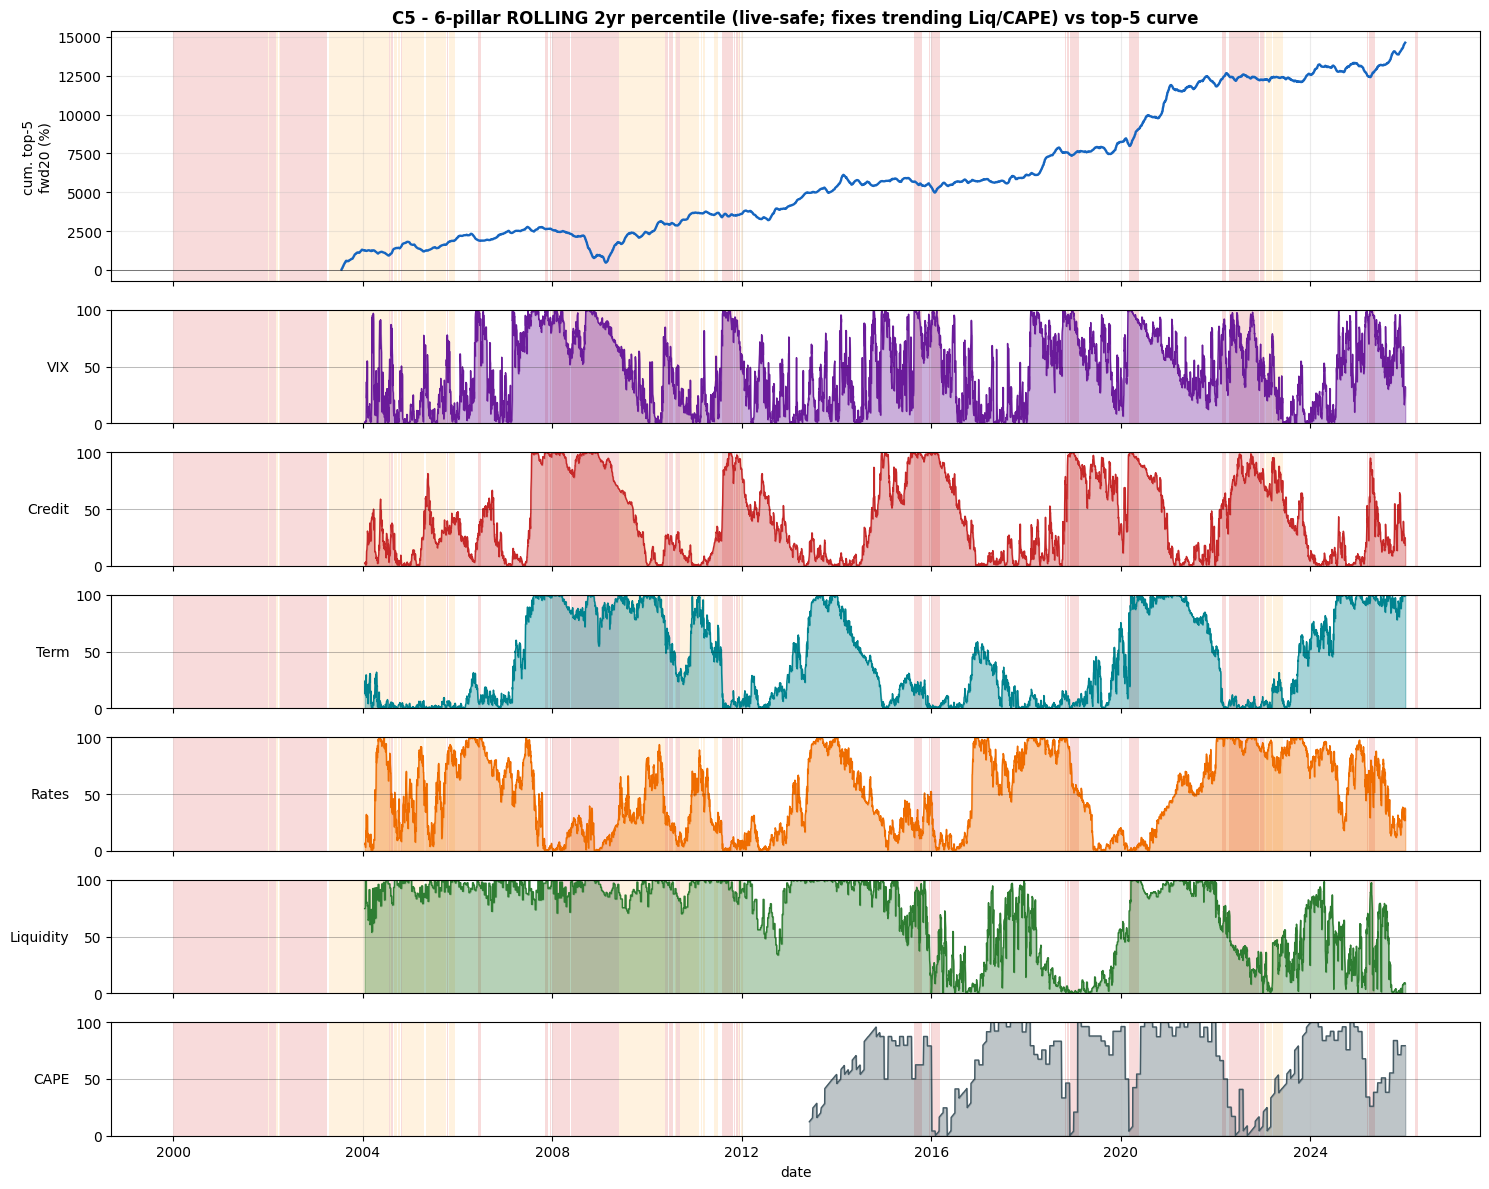

In [13]:
ROLL = 504                                                 # ~2yr trading days
p = et[["date"]+pil].sort_values("date").reset_index(drop=True)
for c in pil:                                              # rolling percentile: rank of today within trailing 2yr (live-safe)
    p[c+"_rp"] = p[c].rolling(ROLL, min_periods=126).apply(lambda x:(x.iloc[-1]>=x).mean(), raw=False)
curve5 = (daily_topn(topn[topn.date>=p.date.min()], 5, "fwd20")*100).cumsum()

fig, ax = plt.subplots(7, 1, figsize=(15, 12), sharex=True, gridspec_kw={"height_ratios":[2.2]+[1]*6})
shade(ax[0], dd); ax[0].plot(curve5.index, curve5.values, color="#1565c0", lw=1.7)
ax[0].axhline(0,color="k",lw=.7,alpha=.5); ax[0].grid(alpha=.25); ax[0].set_ylabel("cum. top-5\nfwd20 (%)")
ax[0].set_title("C5 - 6-pillar ROLLING 2yr percentile (live-safe; fixes trending Liq/CAPE) vs top-5 curve", weight="bold")
for a, c, col in zip(ax[1:], pil, pcols):
    shade(a, dd); a.fill_between(p.date, 0, p[c+"_rp"]*100, color=col, alpha=.35); a.plot(p.date, p[c+"_rp"]*100, color=col, lw=1)
    a.set_ylim(0,100); a.set_yticks([0,50,100]); a.axhline(50,color="k",lw=.5,alpha=.3); a.grid(alpha=.2)
    a.set_ylabel(nice[c], rotation=0, ha="right", va="center", fontsize=10)
ax[-1].set_xlabel("date"); plt.tight_layout(); plt.show()
# READ: Liquidity now DIPS below 50% in QT windows (2018, 2022) instead of pinning at 100%; CAPE shows
#       cyclical position not a monotone ramp. Credit/VIX spike to ~100% into the red bear bands.

### Read — the raw returns, the regime picture, and the pillar-transform fix

- **The cumulative curve was summing per-day top-5 mean fwd20 (C3).** Each point is one deploy-date's
  basket outcome. The red mean-line is +ve in bull/rebound panels (drift) and near/below 0 with fat
  downside scatter in GFC/bear — the cumulative slope is just the running total of these.
- **Whole-period (C4): the regime change is visible.** The bear bands (2001-02, 2008, 2020, 2022) sit
  exactly on the flat/declining stretches of the cumulative curve; between them it climbs. Confirms at
  25-yr scale that the edge is a bull-regime property and the drawdowns are regime-timed, not random —
  the case for the point-8 governor.
- **Pillar data facts (user Qs), both REAL:** (i) CAPE genuinely starts 2012-12 (`CAPE_OURS`,
  self-computed; earlier is absent, cf [[project_cape_ours_pillar]]). (ii) Liquidity pinned >50% was a
  TRANSFORM bug, not data — Net Liquidity trends up (+0.96 with time), and an EXPANDING percentile of a
  trending series saturates at ~100%. Fixed with a rolling 2yr percentile (C5): Liq now dips in QT
  (2018/2022), CAPE shows cyclical position. Lesson for any future pillar viz: use a rolling window for
  trending pillars, expanding is only safe for mean-reverting ones.
- **⚠️ Rolling percentile is still a VISUALIZATION**, not a fitted feature; the consolidated live-safe
  signal remains `stress_ew_vix` ([[project_entry_timing_macro_axis]]). Same directional/no-exit caveats.

In [14]:
from scipy.stats import spearmanr
PIL = ["pil_vix","pil_credit","pil_term","pil_rates","pil_liq","pil_cape"]
e = et.sort_values("date").reset_index(drop=True).copy()
for c in PIL:                                              # rolling 2yr pct (live-safe; handles trending liq/cape)
    e[c+"_rp"] = e[c].rolling(504, min_periods=126).apply(lambda x:(x.iloc[-1]>=x).mean(), raw=False)

SIGS = {"pil_vix_rp":"VIX 2yr-pct","pil_credit_rp":"Credit 2yr-pct","pil_term_rp":"Term 2yr-pct",
        "pil_rates_rp":"Rates 2yr-pct","pil_liq_rp":"Liquidity 2yr-pct","pil_cape_rp":"CAPE 2yr-pct",
        "stress_ew_vix":"stress composite","vix_close":"VIX raw level","spy_above200":"SPY>200d",
        "spy_ret60":"SPY 60d mom"}
print("signals ready:", len(SIGS))

signals ready: 10


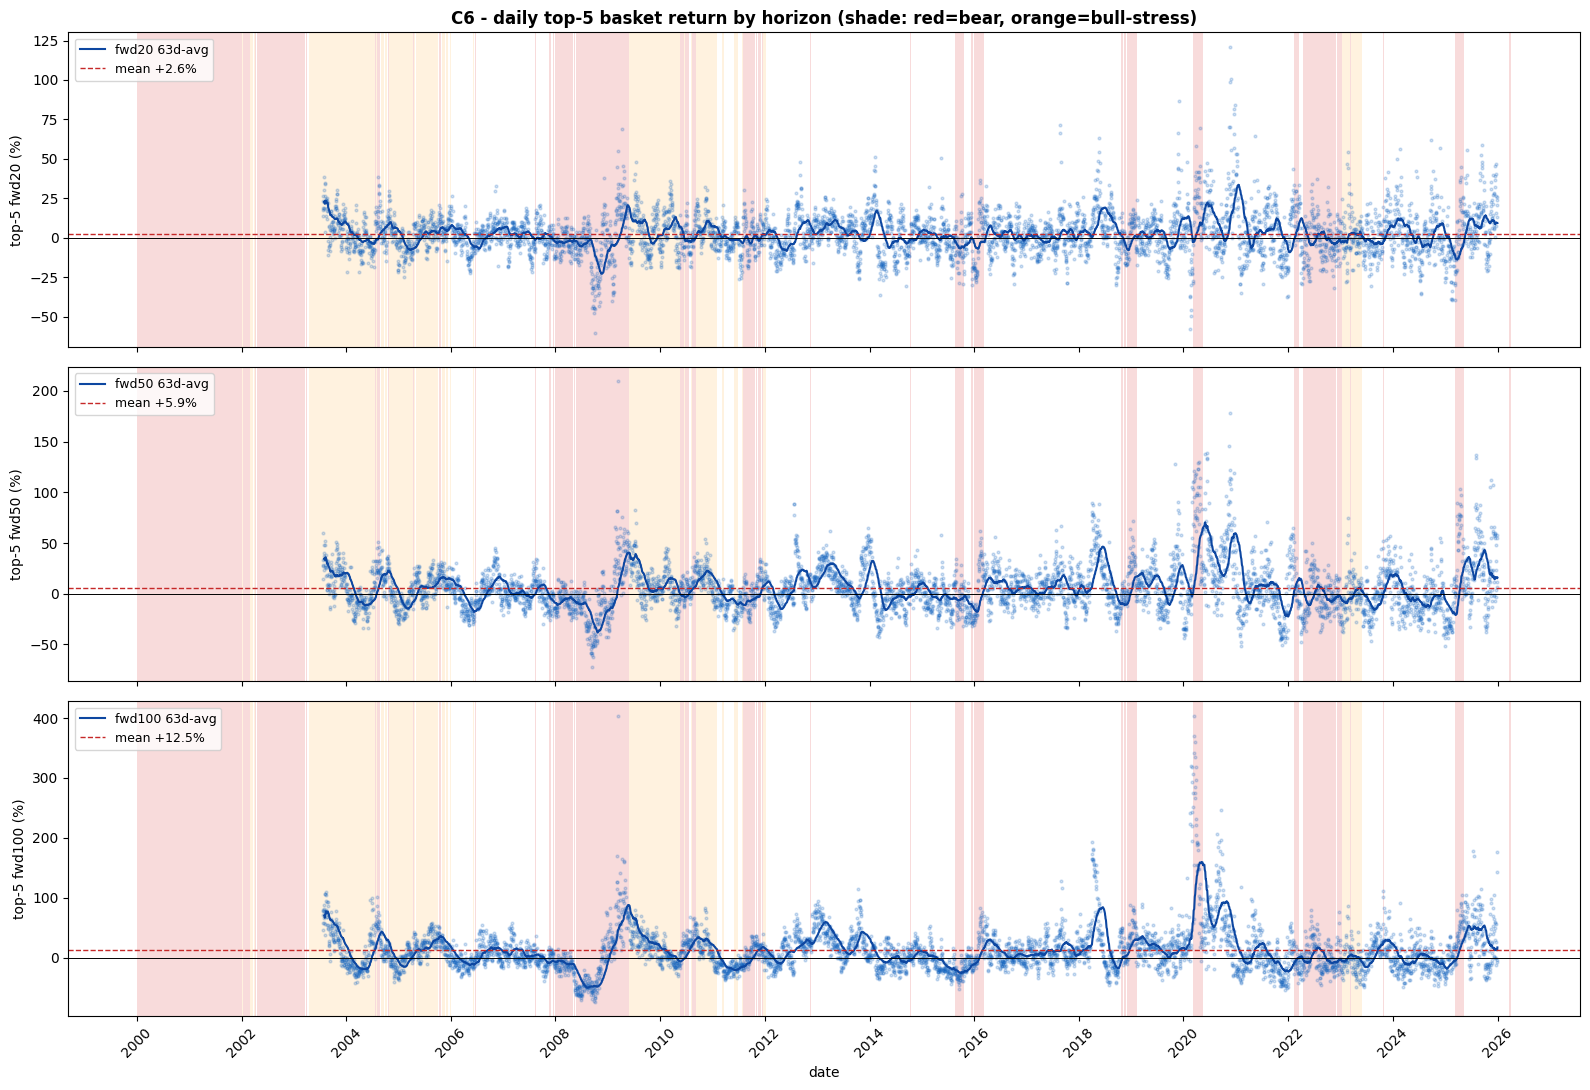

In [15]:
from matplotlib.dates import YearLocator
dd = pd.read_parquet(ROOT/"data/model_output_eda/regime_state/regime_state_daily_dd.parquet")[["date","state"]]
def shade(ax, reg):
    r = reg.sort_values("date").reset_index(drop=True); r["blk"]=(r.state!=r.state.shift()).cumsum()
    for _,g in r.groupby("blk"):
        col={"bear":"#e57373","bull-stress":"#ffcc80"}.get(g.state.iloc[0])
        if col: ax.axvspan(g.date.iloc[0], g.date.iloc[-1], color=col, alpha=.25, lw=0)

fig, ax = plt.subplots(3, 1, figsize=(16, 11), sharex=True)
for a, h in zip(ax, ["fwd20","fwd50","fwd100"]):
    shade(a, dd); y = e.set_index("date")[h]*100
    a.scatter(y.index, y.values, s=4, alpha=.2, color="#1565c0")
    a.plot(y.rolling(63,min_periods=10).mean().index, y.rolling(63,min_periods=10).mean().values,
           color="#0d47a1", lw=1.5, label=f"{h} 63d-avg")
    a.axhline(0,color="k",lw=.7); a.axhline(y.mean(),color="#c62828",ls="--",lw=1,label=f"mean {y.mean():+.1f}%")
    a.set_ylabel(f"top-5 {h} (%)"); a.legend(loc="upper left", fontsize=9)
ax[0].set_title("C6 - daily top-5 basket return by horizon (shade: red=bear, orange=bull-stress)", weight="bold")
ax[-1].set_xlabel("date"); ax[-1].xaxis.set_major_locator(YearLocator(2)); ax[-1].tick_params(axis="x", labelrotation=45)
plt.tight_layout(); plt.show()
# READ: mean return grows with horizon (+2.6% -> +5.9% -> +12.1%); the 2020 rebound spike dominates fwd100.

In [16]:
rows = []
for s, lbl in SIGS.items():
    row = {"signal": lbl}
    for h in ("fwd20","fwd50","fwd100"):
        d = e[[s,h]].dropna(); row[f"rho_{h}"] = spearmanr(d[s], d[h]).correlation
    d = e[[s,"fwd100"]].dropna().copy()
    if d[s].nunique() <= 2:
        g = d.groupby(s)["fwd100"].mean()*100; row["spread_T3_T1"] = g.iloc[-1]-g.iloc[0]
    else:
        d["t"] = pd.qcut(d[s], 3, labels=[0,1,2], duplicates="drop")
        g = d.groupby("t", observed=True)["fwd100"].mean()*100; row["spread_T3_T1"] = g.iloc[-1]-g.iloc[0]
    rows.append(row)
q = pd.DataFrame(rows).sort_values("spread_T3_T1", ascending=False)
pd.set_option("display.float_format", lambda x: f"{x:+.3f}")
print(q.to_string(index=False))
# READ: VIX/stress/credit separate high-return periods (+9..+11.5% fwd100 spread); rates/CAPE invert;
#       SPY>200d is NEGATIVE (rebound lives sub-200d). rho weak everywhere -> a TILT, not a gate.

           signal  rho_fwd20  rho_fwd50  rho_fwd100  spread_T3_T1
      VIX 2yr-pct     +0.026     +0.023      +0.048       +11.482
    VIX raw level     +0.036     +0.056      +0.078       +10.962
 stress composite     +0.014     +0.082      +0.084       +10.463
   Credit 2yr-pct     -0.012     +0.040      +0.047        +9.612
     Term 2yr-pct     +0.033     +0.034      +0.013        +6.175
      SPY 60d mom     +0.017     +0.017      +0.002        -3.257
Liquidity 2yr-pct     +0.020     -0.036      -0.065        -4.513
         SPY>200d     +0.022     +0.016      -0.004        -5.098
     CAPE 2yr-pct     +0.041     -0.021      -0.070        -8.257
    Rates 2yr-pct     -0.036     -0.085      -0.070        -8.942


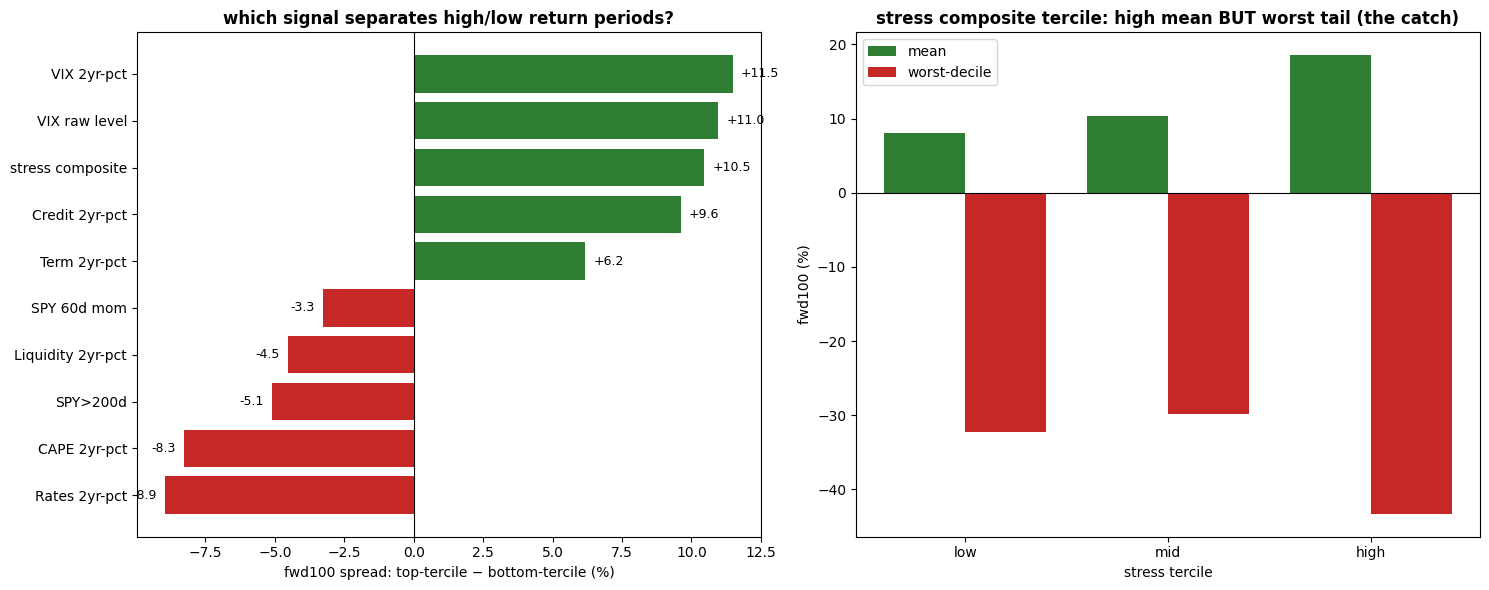

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
qs = q.sort_values("spread_T3_T1")
cols = ["#c62828" if v<0 else "#2e7d32" for v in qs["spread_T3_T1"]]
ax[0].barh(qs["signal"], qs["spread_T3_T1"], color=cols); ax[0].axvline(0, color="k", lw=.8)
for i,v in enumerate(qs["spread_T3_T1"]):
    ax[0].text(v+(0.3 if v>=0 else -0.3), i, f"{v:+.1f}", va="center", ha="left" if v>=0 else "right", fontsize=9)
ax[0].set_xlabel("fwd100 spread: top-tercile − bottom-tercile (%)")
ax[0].set_title("which signal separates high/low return periods?", weight="bold")

d = e[["stress_ew_vix","fwd100"]].dropna().copy(); d["t"] = pd.qcut(d["stress_ew_vix"], 3, labels=["low","mid","high"])
gm = d.groupby("t", observed=True)["fwd100"].mean()*100
gw = d.groupby("t", observed=True)["fwd100"].apply(lambda x:x.nsmallest(max(1,len(x)//10)).mean())*100
x = np.arange(3)
ax[1].bar(x-.2, gm.values, .4, label="mean", color="#2e7d32"); ax[1].bar(x+.2, gw.values, .4, label="worst-decile", color="#c62828")
ax[1].set_xticks(x); ax[1].set_xticklabels(gm.index); ax[1].axhline(0, color="k", lw=.8); ax[1].legend()
ax[1].set_title("stress composite tercile: high mean BUT worst tail (the catch)", weight="bold")
ax[1].set_ylabel("fwd100 (%)"); ax[1].set_xlabel("stress tercile")
plt.tight_layout(); plt.show()

### Read — high/low-return periods ARE quantifiable by macro, on ONE axis, with a tail cost

- **Yes, macro separates high- from low-return deploy periods — but it's all ONE axis (stress/VIX).**
  fwd100 top−bottom-tercile spread: VIX +11.5%, VIX-raw +11.0%, stress composite +10.5%, credit +9.6%.
  Rates (−8.9%) and CAPE (−8.3%) are the same axis with the sign flipped (expensive/tight → worse).
  The consolidated `stress_ew_vix` is NOT better than raw VIX here — VIX alone carries most of it
  ([[project_entry_timing_macro_axis]]: VIX ≈ the realized-vol / bear axis, corr +0.87 with spy_vol20).
- **SPY-trend does NOT separate return LEVEL** (SPY>200d spread −5.1%, momentum ~0) — because the high
  returns are the rebounds that happen BELOW 200d. SPY-trend is a DOWNSIDE/tail gate (point-8 finding a),
  not a return-level ranker. Two different jobs: stress/VIX ranks the MEAN, SPY-trend contains the TAIL.
- **The catch: the high-return tercile is also the worst-tail tercile.** High-stress: mean +18.5% but
  worst-decile −43.3% (vs low-stress mean +8.1% / worst-decile −32.3%). High mean, high variance — the
  falling knife. So "deploy more when stress is high" only survives WITH the SPY>200d gate on top (which
  removes the sub-200d knife) — the exact point-8 governor (b). Chasing raw stress ungated buys the tail.
- **All |ρ|≤0.09 → these are TILTS not gates**, and they rank the deploy-DATE return level, separate
  from m01's within-basket name selection. ⚠️ directional close-to-close top-5 mean returns, no
  exits/sizing; rolling percentiles are live-safe but the tercile CUTS are full-sample (EDA framing) —
  an expanding cut would be needed to size live capital.